In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


## load dataset

In [2]:
df = pd.read_csv(
    "learntwin_student_interactions.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10000, 10)


,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


In [3]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df = df.sort_values(
    by=["student_id", "timestamp"]
).reset_index(drop=True)

print("Dataset sorted successfully!")

Dataset sorted successfully!


In [4]:
concept_encoder = LabelEncoder()

df["concept_encoded"] = (
    concept_encoder.fit_transform(
        df["concept"]
    )
)

print(
    "Number of concepts:",
    len(concept_encoder.classes_)
)

print(
    concept_encoder.classes_
)

Number of concepts: 20
['AGGREGATE FUNCTIONS' 'FOREIGN KEY' 'GROUP BY' 'HAVING' 'INDEXING'
 'INNER JOIN' 'JOINS' 'LEFT JOIN' 'NORMALIZATION' 'ORDER BY' 'PRIMARY KEY'
 'RIGHT JOIN' 'SELECT' 'STORED PROCEDURES' 'SUBQUERIES' 'TRANSACTIONS'
 'TRIGGERS' 'UNION' 'VIEWS' 'WHERE']


## Create sequences

In [5]:
SEQUENCE_LENGTH = 10

X_concept = []
X_numeric = []
y = []

target_attempts = []
target_students = []

for student_id, student_data in df.groupby(
    "student_id"
):

    student_data = student_data.sort_values(
        "attempt"
    ).reset_index(drop=True)

    for i in range(
        SEQUENCE_LENGTH,
        len(student_data)
    ):

        history_data = student_data.iloc[
            i - SEQUENCE_LENGTH:i
        ]

        current_data = student_data.iloc[i]

        # Concept history
        X_concept.append(
            history_data[
                "concept_encoded"
            ].values
        )

        # Numerical history
        X_numeric.append(
            history_data[
                [
                    "correct",
                    "difficulty",
                    "time_gap_days",
                    "days_since_practice"
                ]
            ].values
        )

        # Target
        y.append(
            current_data["correct"]
        )

        # Information about target
        target_attempts.append(
            current_data["attempt"]
        )

        target_students.append(
            current_data["student_id"]
        )

## Convert everything to NumPy

In [6]:
X_concept = np.array(
    X_concept,
    dtype=np.int32
)

X_numeric = np.array(
    X_numeric,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.float32
)

target_attempts = np.array(
    target_attempts,
    dtype=int
)

target_students = np.array(
    target_students
)

print("X_concept:", X_concept.shape)
print("X_numeric:", X_numeric.shape)
print("y:", y.shape)
print("target_attempts:", target_attempts.shape)

X_concept: (9000, 10)
X_numeric: (9000, 10, 4)
y: (9000,)
target_attempts: (9000,)


## Train/Test split

In [7]:
train_mask = target_attempts <= 80
test_mask = target_attempts > 80

# Training
X_concept_train = X_concept[train_mask]
X_numeric_train = X_numeric[train_mask]
y_train = y[train_mask]

# Testing
X_concept_test = X_concept[test_mask]
X_numeric_test = X_numeric[test_mask]
y_test = y[test_mask]

# Extra information
target_students_train = target_students[
    train_mask
]

target_students_test = target_students[
    test_mask
]

target_attempts_train = target_attempts[
    train_mask
]

target_attempts_test = target_attempts[
    test_mask
]

print(
    "Training concept shape:",
    X_concept_train.shape
)

print(
    "Training numeric shape:",
    X_numeric_train.shape
)

print(
    "Training target shape:",
    y_train.shape
)

print()

print(
    "Testing concept shape:",
    X_concept_test.shape
)

print(
    "Testing numeric shape:",
    X_numeric_test.shape
)

print(
    "Testing target shape:",
    y_test.shape
)

Training concept shape: (7000, 10)
Training numeric shape: (7000, 10, 4)
Training target shape: (7000,)

Testing concept shape: (2000, 10)
Testing numeric shape: (2000, 10, 4)
Testing target shape: (2000,)


## Scale numerical features

In [8]:
scaler = StandardScaler()

train_numeric_2d = X_numeric_train.reshape(
    -1,
    X_numeric_train.shape[-1]
)

test_numeric_2d = X_numeric_test.reshape(
    -1,
    X_numeric_test.shape[-1]
)

scaler.fit(
    train_numeric_2d
)

X_numeric_train = scaler.transform(
    train_numeric_2d
).reshape(
    X_numeric_train.shape
)

X_numeric_test = scaler.transform(
    test_numeric_2d
).reshape(
    X_numeric_test.shape
)

print(
    "Training numeric shape:",
    X_numeric_train.shape
)

print(
    "Testing numeric shape:",
    X_numeric_test.shape
)

Training numeric shape: (7000, 10, 4)
Testing numeric shape: (2000, 10, 4)


## Check class distribution

In [9]:
print("Training class distribution:")
print(
    pd.Series(y_train).value_counts()
)

print()

print("Testing class distribution:")
print(
    pd.Series(y_test).value_counts()
)

print()

print("Training percentages:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    * 100
)

Training class distribution:
0.0    4941
1.0    2059
Name: count, dtype: int64

Testing class distribution:
0.0    1413
1.0     587
Name: count, dtype: int64

Training percentages:
0.0    70.585714
1.0    29.414286
Name: proportion, dtype: float64


## Calculate class weights

In [10]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(
        classes,
        class_weights_array
    )
)

print("Class weights:")
print(class_weights)

Class weights:
{np.float32(0.0): np.float64(0.7083586318558996), np.float32(1.0): np.float64(1.6998542982030111)}


## Load the LSTM

In [11]:
lstm_model = load_model(
    "learntwin_lstm_model.keras"
)

print(
    "LSTM model loaded successfully!"
)

ValueError: File not found: filepath=learntwin_lstm_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ concept_input (InputLayer)    │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_embedding (Embedding) │ (None, 10, 16)            │             320 │ concept_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_input (InputLayer)    │ (None, 10, 4)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_lstm (LSTM)           │ (None, 64)                │          20,736 │ concept_embedding[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_lstm (LSTM)           │ (None, 64)                │          17,664 │ numeric_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ combined_features             │ (None, 128)               │               0 │ concept_lstm[0][0],        │
│ (Concatenate)                 │                           │                 │ numeric_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ combined_features[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ prediction (Dense)            │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 147,269 (575.27 KB)

 Trainable params: 49,089 (191.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,180 (383.52 KB)

In [ ]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(
    "LSTM model compiled successfully!"
)

LSTM model compiled successfully!


## Early stopping

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print(
    "Early stopping configured!"
)

Early stopping configured!


In [ ]:
history = lstm_model.fit(
    [
        X_concept_train,
        X_numeric_train
    ],
    y_train,

    validation_split=0.2,

    epochs=30,
    batch_size=64,

    class_weight=class_weights,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6091 - loss: 0.6978 - val_accuracy: 0.4757 - val_loss: 0.6920
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5421 - loss: 0.6912 - val_accuracy: 0.4964 - val_loss: 0.6901
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4971 - loss: 0.6897 - val_accuracy: 0.4607 - val_loss: 0.6925
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4846 - loss: 0.6884 - val_accuracy: 0.4943 - val_loss: 0.6842
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5129 - loss: 0.6877 - val_accuracy: 0.4029 - val_loss: 0.7051
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5170 - loss: 0.6872 - val_accuracy: 0.3771 - val_loss: 0.7085
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5127 - loss: 0.6853 - val_accuracy: 0.3914 - val_loss: 0.7079
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5046 - loss: 0.6836 - val_accuracy: 0.4714 - val_loss:

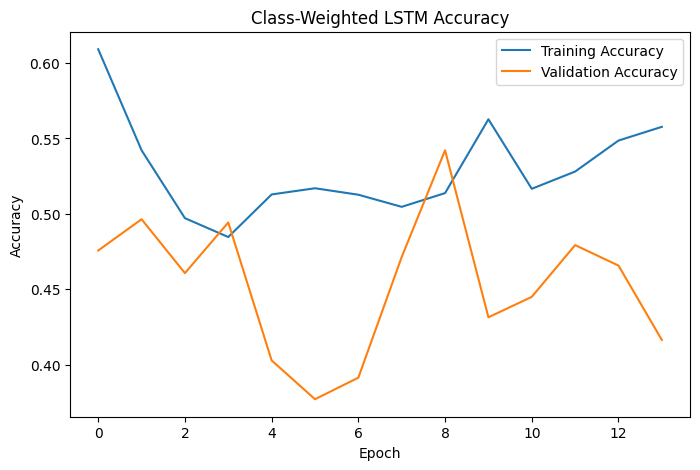

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Class-Weighted LSTM Accuracy"
)

plt.legend()

plt.show()

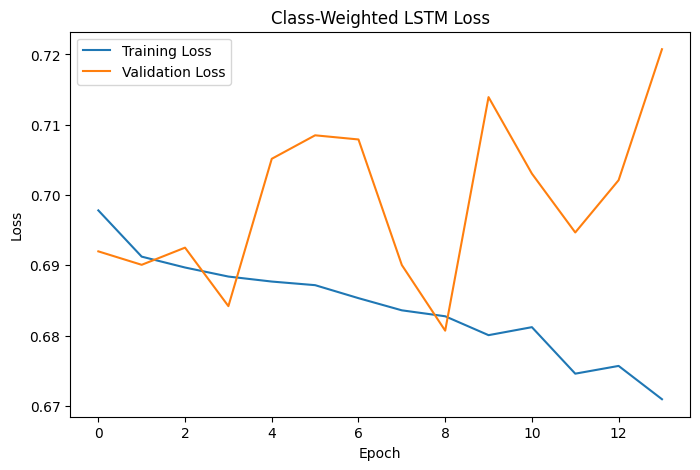

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Class-Weighted LSTM Loss"
)

plt.legend()

plt.show()

## Evaluate lstm_model

In [ ]:
test_loss, test_accuracy = (
    lstm_model.evaluate(
        [
            X_concept_test,
            X_numeric_test
        ],
        y_test,
        verbose=0
    )
)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

Test Loss: 0.6753
Test Accuracy: 0.5715


In [ ]:
lstm_probability = (
    lstm_model.predict(
        [
            X_concept_test,
            X_numeric_test
        ],
        verbose=0
    )
    .ravel()
)

print(
    "First 20 probabilities:"
)

print(
    lstm_probability[:20]
)

First 20 probabilities:
[0.5369812  0.526685   0.4835956  0.43060288 0.35852152 0.44796172
 0.47121057 0.4689117  0.43618137 0.42006254 0.42621404 0.4222636
 0.3946139  0.4491518  0.45407966 0.44854718 0.49266842 0.5073755
 0.4172877  0.3347817 ]


## Convert probability to prediction

In [ ]:
lstm_pred = (
    lstm_probability >= 0.5
).astype(int)

print(
    "First 20 predictions:"
)

print(
    lstm_pred[:20]
)

First 20 predictions:
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [ ]:
lstm_accuracy = accuracy_score(
    y_test,
    lstm_pred
)

lstm_precision = precision_score(
    y_test,
    lstm_pred,
    zero_division=0
)

lstm_recall = recall_score(
    y_test,
    lstm_pred,
    zero_division=0
)

lstm_f1 = f1_score(
    y_test,
    lstm_pred,
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test,
    lstm_probability
)

print(
    "========== FINAL LSTM RESULTS =========="
)

print(
    "Accuracy :",
    round(lstm_accuracy, 4)
)

print(
    "Precision:",
    round(lstm_precision, 4)
)

print(
    "Recall   :",
    round(lstm_recall, 4)
)

print(
    "F1 Score :",
    round(lstm_f1, 4)
)

print(
    "ROC-AUC  :",
    round(lstm_roc_auc, 4)
)

========== FINAL LSTM RESULTS ==========
Accuracy : 0.5715
Precision: 0.2961
Recall   : 0.3339
F1 Score : 0.3139
ROC-AUC  : 0.496


In [ ]:
print(
    classification_report(
        y_test,
        lstm_pred,

        target_names=[
            "Incorrect",
            "Correct"
        ],

        zero_division=0
    )
)

              precision    recall  f1-score   support

   Incorrect       0.71      0.67      0.69      1413
     Correct       0.30      0.33      0.31       587

    accuracy                           0.57      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.59      0.57      0.58      2000



## Confusion matrix

In [ ]:
lstm_cm = confusion_matrix(
    y_test,
    lstm_pred
)

print(
    "LSTM Confusion Matrix:"
)

print(lstm_cm)

LSTM Confusion Matrix:
[[947 466]
 [391 196]]


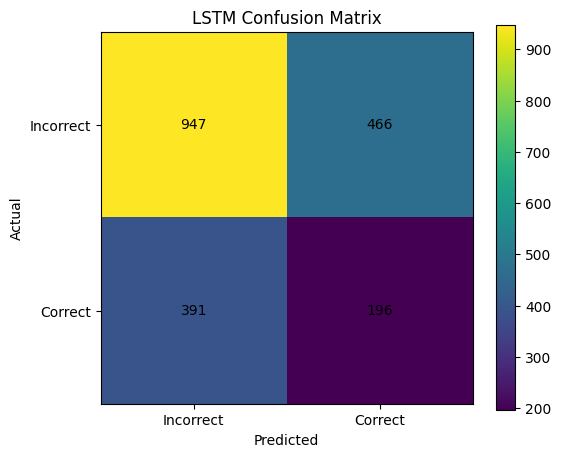

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(lstm_cm)

plt.title(
    "LSTM Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    [
        "Incorrect",
        "Correct"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Incorrect",
        "Correct"
    ]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            lstm_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [ ]:
print(
    "Actual class distribution:"
)

print(
    pd.Series(y_test)
    .value_counts()
)

print()

print(
    "Predicted class distribution:"
)

print(
    pd.Series(lstm_pred)
    .value_counts()
)

Actual class distribution:
0.0    1413
1.0     587
Name: count, dtype: int64

Predicted class distribution:
0    1338
1     662
Name: count, dtype: int64


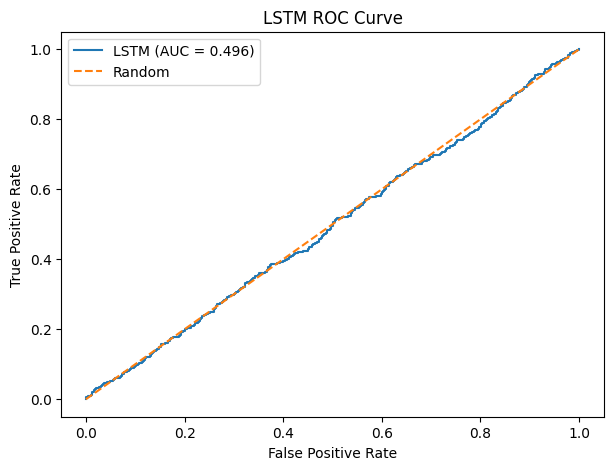

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    lstm_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"LSTM (AUC = {lstm_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "LSTM ROC Curve"
)

plt.legend()

plt.show()

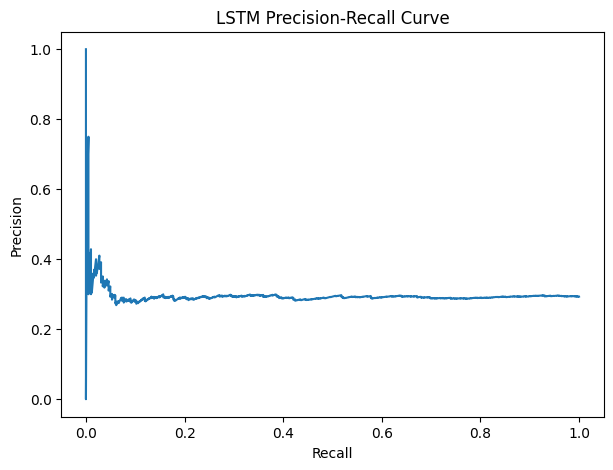

In [ ]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        lstm_probability
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "LSTM Precision-Recall Curve"
)

plt.show()

In [ ]:
lstm_model.save(
    "learntwin_lstm_model.keras"
)

print(
    "Improved LSTM model saved successfully!"
)

Improved LSTM model saved successfully!


In [ ]:
lstm_results = pd.DataFrame({
    "Model": [
        "LSTM"
    ],
    "Accuracy": [
        lstm_accuracy
    ],
    "Precision": [
        lstm_precision
    ],
    "Recall": [
        lstm_recall
    ],
    "F1": [
        lstm_f1
    ],
    "ROC_AUC": [
        lstm_roc_auc
    ]
})

lstm_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LSTM,0.5715,0.296073,0.333901,0.313851,0.496035


In [ ]:
lstm_results.to_csv(
    "learntwin_lstm_results.csv",
    index=False
)

print(
    "LSTM evaluation results saved!"
)

LSTM evaluation results saved!


## Create final model comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Knowledge Model",
        "Forgetting Prediction Model",
        "LSTM Deep Learning Model"
    ],

    "Accuracy": [
        0.7065,
        0.6860,
        lstm_accuracy
    ],

    "Precision": [
        0.0000,
        0.7069,
        lstm_precision
    ],

    "Recall": [
        0.0000,
        0.7339,
        lstm_recall
    ],

    "F1 Score": [
        0.0000,
        0.7201,
        lstm_f1
    ],

    "ROC-AUC": [
        0.5720,
        0.7297,
        lstm_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Knowledge Model,0.7065,0.000000,0.000000,0.000000,0.572000
1,Forgetting Prediction Model,0.6860,0.706900,0.733900,0.720100,0.729700
2,LSTM Deep Learning Model,0.5715,0.296073,0.333901,0.313851,0.496035


## the best model

In [ ]:
best_f1_model = comparison.loc[
    comparison["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Model"
]

print(
    "Best model based on F1 Score:",
    best_f1_model
)

print(
    "Best model based on ROC-AUC:",
    best_auc_model
)

Best model based on F1 Score: Forgetting Prediction Model
Best model based on ROC-AUC: Forgetting Prediction Model


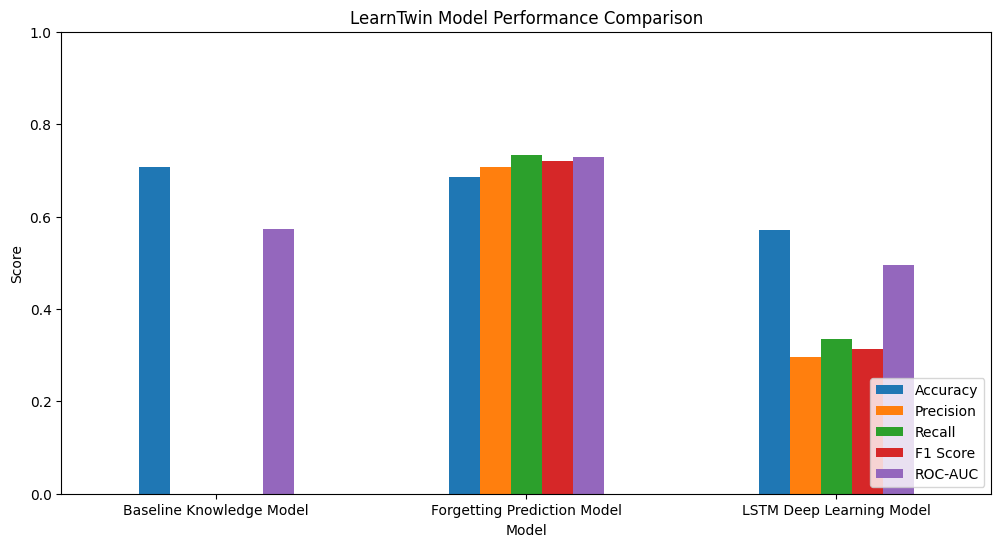

In [ ]:
comparison_plot = comparison.set_index(
    "Model"
)

comparison_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "LearnTwin Model Performance Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.show()

## Analyze LSTM errors

In [ ]:
error_analysis = pd.DataFrame({
    "student_id": target_students_test,
    "attempt": target_attempts_test,
    "actual": y_test.astype(int),
    "predicted": lstm_pred,
    "probability": lstm_probability
})

error_analysis["error"] = (
    error_analysis["actual"] !=
    error_analysis["predicted"]
)

print(
    "Total test samples:",
    len(error_analysis)
)

print(
    "Total errors:",
    error_analysis["error"].sum()
)

print(
    "Error rate:",
    round(
        error_analysis["error"].mean(),
        4
    )
)

Total test samples: 2000
Total errors: 857
Error rate: 0.4285


In [ ]:
wrong_predictions = error_analysis[
    error_analysis["error"] == True
]

print(
    "Number of wrong predictions:",
    len(wrong_predictions)
)

wrong_predictions.head(20)

Number of wrong predictions: 857


,student_id,attempt,actual,predicted,probability,error
0,S001,81,0,1,0.536981,True
1,S001,82,0,1,0.526685,True
8,S001,89,1,0,0.436181,True
17,S001,98,0,1,0.507375,True
18,S001,99,1,0,0.417288,True
21,S002,82,1,0,0.461361,True
24,S002,85,1,0,0.471852,True
26,S002,87,1,0,0.409145,True
30,S002,91,0,1,0.505753,True
31,S002,92,1,0,0.494881,True


## Analyze prediction confidence

In [ ]:
error_analysis["confidence"] = np.abs(
    error_analysis["probability"] - 0.5
)

print(
    error_analysis[
        [
            "actual",
            "predicted",
            "probability",
            "confidence"
        ]
    ].head(20)
)

    actual  predicted  probability  confidence
0        0          1     0.536981    0.036981
1        0          1     0.526685    0.026685
2        0          0     0.483596    0.016404
3        0          0     0.430603    0.069397
4        0          0     0.358522    0.141478
5        0          0     0.447962    0.052038
6        0          0     0.471211    0.028789
7        0          0     0.468912    0.031088
8        1          0     0.436181    0.063819
9        0          0     0.420063    0.079937
10       0          0     0.426214    0.073786
11       0          0     0.422264    0.077736
12       0          0     0.394614    0.105386
13       0          0     0.449152    0.050848
14       0          0     0.454080    0.045920
15       0          0     0.448547    0.051453
16       0          0     0.492668    0.007332
17       0          1     0.507375    0.007375
18       1          0     0.417288    0.082712
19       0          0     0.334782    0.165218


In [ ]:
uncertain_predictions = error_analysis[
    error_analysis["probability"].between(
        0.40,
        0.60
    )
]

print(
    "Uncertain predictions:",
    len(uncertain_predictions)
)

uncertain_predictions.head(20)

Uncertain predictions: 1749


,student_id,attempt,actual,predicted,probability,error,confidence
0,S001,81,0,1,0.536981,True,0.036981
1,S001,82,0,1,0.526685,True,0.026685
2,S001,83,0,0,0.483596,False,0.016404
3,S001,84,0,0,0.430603,False,0.069397
5,S001,86,0,0,0.447962,False,0.052038
6,S001,87,0,0,0.471211,False,0.028789
7,S001,88,0,0,0.468912,False,0.031088
8,S001,89,1,0,0.436181,True,0.063819
9,S001,90,0,0,0.420063,False,0.079937
10,S001,91,0,0,0.426214,False,0.073786


## Save final comparison

In [ ]:
comparison.to_csv(
    "learntwin_model_comparison.csv",
    index=False
)

print(
    "Final model comparison saved successfully!"
)

Final model comparison saved successfully!


## Save error analysis

In [ ]:
error_analysis.to_csv(
    "learntwin_lstm_error_analysis.csv",
    index=False
)

print(
    "LSTM error analysis saved successfully!"
)

LSTM error analysis saved successfully!


## 7.29A — Check the target distribution

In [ ]:
print("Training target distribution:")
print(pd.Series(y_train).value_counts())

print("\nTraining target percentage:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    * 100
)

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts())

print("\nTest target percentage:")
print(
    pd.Series(y_test)
    .value_counts(normalize=True)
    * 100
)

Training target distribution:
0.0    4941
1.0    2059
Name: count, dtype: int64

Training target percentage:
0.0    70.585714
1.0    29.414286
Name: proportion, dtype: float64

Test target distribution:
0.0    1413
1.0     587
Name: count, dtype: int64

Test target percentage:
0.0    70.65
1.0    29.35
Name: proportion, dtype: float64


## Check LSTM prediction distribution

In [ ]:
print("Predicted distribution:")
print(
    pd.Series(lstm_pred).value_counts()
)

print("\nPredicted percentage:")
print(
    pd.Series(lstm_pred)
    .value_counts(normalize=True)
    * 100
)

Predicted distribution:
0    1338
1     662
Name: count, dtype: int64

Predicted percentage:
0    66.9
1    33.1
Name: proportion, dtype: float64


## Check probability statistics

In [ ]:
print(
    pd.Series(lstm_probability).describe()
)

count    2000.000000
mean        0.467819
std         0.058332
min         0.238685
25%         0.432393
50%         0.477644
75%         0.510056
max         0.611606
dtype: float64


In [ ]:
print("Probability percentiles:")

print(
    np.percentile(
        lstm_probability,
        [0, 10, 25, 50, 75, 90, 100]
    )
)

Probability percentiles:
[0.23868504 0.38939718 0.43239304 0.47764431 0.51005569 0.53256435
 0.61160624]


In [ ]:
prob_correct = lstm_probability[y_test == 1]
prob_incorrect = lstm_probability[y_test == 0]

print("========== ACTUAL INCORRECT ==========")
print(
    pd.Series(prob_incorrect).describe()
)

print("\n========== ACTUAL CORRECT ==========")
print(
    pd.Series(prob_correct).describe()
)

========== ACTUAL INCORRECT ==========
count    1413.000000
mean        0.467886
std         0.058475
min         0.238685
25%         0.433908
50%         0.477739
75%         0.510246
max         0.611606
dtype: float64

========== ACTUAL CORRECT ==========
count    587.000000
mean       0.467658
std        0.058036
min        0.246827
25%        0.428842
50%        0.477605
75%        0.509575
max        0.602757
dtype: float64
